# PatchCore — Anomaly Detection con Feature di Backbone

**PatchCore** è un algoritmo di anomaly detection *senza supervisione* (unsupervised) che sfrutta le rappresentazioni intermedie di una rete neurale preaddestrata per costruire un profilo di normalità.

## Idea di fondo

PatchCore si basa su un'intuizione semplice ma potente:
> *Una rete CNN preaddestrata su ImageNet produce, nei layer intermedi, feature ricche e generalizzabili. Se addestriamo il modello **solo su immagini normali**, le patch anomale avranno feature lontane da quelle viste in training.*

## Pipeline

```
Immagini normali (train)
        │
        ▼
┌─────────────────────┐
│  Backbone CNN        │  ← ResNet18 pretrained (layer2 + layer3)
│  Feature Extraction  │
└─────────────────────┘
        │  feature patches  (N × 28 × 28 × 384)
        ▼
┌─────────────────────┐
│   Memory Bank        │  ← raccolta di tutte le patch normali
└─────────────────────┘
        │
        ▼
┌─────────────────────┐
│  Coreset Sampling    │  ← sottocampionamento greedy per ridurre la dimensione
└─────────────────────┘
        │
        ▼
┌─────────────────────┐
│  kNN Anomaly Score   │  ← distanza al nearest neighbor nel coreset
└─────────────────────┘
        │
        ▼
    Heatmap di anomalia
```

## Dataset: MVTec AD
Il dataset **MVTec Anomaly Detection** contiene immagini industriali di varie categorie (bottiglia, cavo, texture, ecc.). Le immagini di training contengono solo campioni *normali*; quelle di test includono anche difetti etichettati.

**Paper originale:** Roth et al., *Towards Total Recall in Industrial Anomaly Detection*, CVPR 2022.

In [ ]:
!kaggle datasets download ipythonx/mvtec-ad

Dataset URL: https://www.kaggle.com/datasets/ipythonx/mvtec-ad
License(s): copyright-authors
100% 4.91G/4.91G [00:34<00:00, 153MB/s]



In [ ]:
!unzip mvtec-ad.zip -d mvtect

## Setup: dipendenze e importazioni

Importiamo le librerie necessarie:
- **PyTorch / torchvision** — backbone ResNet18 e gestione dei dati
- **scikit-learn** — kNN e metriche di valutazione
- **PIL / matplotlib** — visualizzazione e manipolazione immagini
- **tqdm** — barre di avanzamento per i cicli lunghi

In [ ]:
import random
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

## Backbone: ResNet18 preaddestrata su ImageNet

Carichiamo ResNet18 con i pesi `IMAGENET1K_V1`. La rete **non viene fine-tuned**: la usiamo solo come estrattore di feature.

Il preprocessing associato ai pesi (`transforms()`) include:
- Resize a 256×256
- Center crop a 224×224
- Normalizzazione con media e deviazione standard di ImageNet

In [ ]:
resnet_18 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


In [ ]:
transform = torchvision.models.ResNet18_Weights.IMAGENET1K_V1.transforms()

In [ ]:
transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Analisi dell'architettura ResNet18

ResNet18 è composta da una serie di blocchi residuali organizzati in quattro gruppi (`layer1`–`layer4`). Per PatchCore utilizziamo le feature degli **strati intermedi** (`layer2` e `layer3`) perché:

- Sono sufficientemente **astratte** da catturare semantica locale
- Conservano ancora **informazione spaziale** (mappa di feature 28×28 e 14×14)
- Evitano il collasso nella rappresentazione globale degli ultimi layer

Ispezioniamo la struttura per capire i nomi da usare negli hook.

In [ ]:
resnet_18

In [ ]:
for name, child in resnet_18.named_children():
  print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


## Estrattore di feature per patch

La funzione `patch_extractor` usa i **forward hook** di PyTorch per catturare gli output intermedi della rete senza modificarne l'architettura.

### Perché layer2 e layer3?

| Layer  | Output shape       | Campo recettivo | Contenuto |
|--------|--------------------|-----------------|-----------|
| layer2 | B × 128 × 28 × 28 | ~40 px          | texture, bordi |
| layer3 | B × 256 × 14 × 14 | ~80 px          | forme, strutture locali |

Per avere la stessa risoluzione spaziale, `layer3` viene **upsampled** a 28×28 con interpolazione bilineare. Le due mappe vengono poi **concatenate** lungo il canale, producendo patch di dimensione `384 = 128 + 256`.

Ogni immagine produce **28×28 = 784 patch**, ciascuna un vettore di 384 valori.

In [ ]:
def patch_extractor(resnet, imgs):
    """Estrae i vettori di feature (patch) da un mini-batch di immagini.

    Usa forward hook su layer2 e layer3 di ResNet18 per catturare le
    feature intermedie senza modificare l'architettura.

    Output sizes (con input 224×224):
        layer2 → B × 128 × 28 × 28
        layer3 → B × 256 × 14 × 14  (upsampliato a 28×28)
        concat → B × 384 × 28 × 28

    Args:
        resnet: modello ResNet18 preaddestrato
        imgs:   tensore di immagini [B, 3, H, W]

    Returns:
        tensore [B*28*28, 384] — una riga per patch
    """
    layer_outputs = []

    def hook(module, inputs, outputs):
        layer_outputs.append(outputs)

    # Registriamo gli hook sui due layer intermedi
    handle2 = resnet.get_submodule("layer2").register_forward_hook(hook)
    handle3 = resnet.get_submodule("layer3").register_forward_hook(hook)

    resnet.eval()
    with torch.no_grad():
        resnet(imgs)

    # Rimozione degli hook dopo la forward pass
    handle2.remove()
    handle3.remove()

    l2_out, l3_out = layer_outputs

    l3_out = torch.nn.functional.interpolate(l3_out, size=(28, 28), mode="bilinear", align_corners=False)

    patches = torch.cat([l2_out, l3_out], dim=1)

    return patches.permute(0, 2, 3, 1).reshape(-1, patches.shape[1])

## Costruzione del Dataset

Definiamo un `Dataset` PyTorch personalizzato per il formato MVTec AD.

### Struttura delle directory MVTec

```
bottle/
├── train/
│   └── good/          ← solo immagini normali (label = 0)
└── test/
    ├── good/          ← campioni normali di test (label = 0)
    ├── broken_large/  ← difetti (label = 1)
    ├── broken_small/  ← difetti (label = 1)
    └── contamination/ ← difetti (label = 1)
```

Il training è **puramente non supervisionato**: nessuna etichetta di difetto viene usata durante la costruzione del memory bank. Le etichette servono solo per la valutazione finale.

### Configurazione percorsi

Modifica `DATA_ROOT` in base al tuo ambiente prima di eseguire le celle successive.

In [ ]:
# Percorso radice del dataset MVTec dopo l'estrazione dello zip
DATA_ROOT = "/content/mvtect"   # Google Colab — cambia se lavori in locale

# Categoria da analizzare (bottle, cable, carpet, grid, hazelnut, ...)
CATEGORY = "bottle"

In [ ]:
class MvTecDataset(Dataset):
    """Dataset per MVTec AD.

    Ogni categoria è suddivisa in sottocartelle (es. 'good', 'broken_large', ...):
    le immagini in 'good' hanno label 0 (normale), tutte le altre label 1 (anomalia).

    Args:
        folder:    percorso alla cartella train/ o test/ della categoria scelta
        transform: trasformazione da applicare all'immagine (opzionale)
    """

    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.files = []

        # Raccoglie tutti i file dalle sottocartelle, conservando il nome della sottocartella
        for subfolder in os.listdir(folder):
            for file in os.listdir(os.path.join(folder, subfolder)):
                self.files.append((file, subfolder))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename, subfolder = self.files[idx]
        fullpath = os.path.join(self.folder, subfolder, filename)

        img = Image.open(fullpath).convert("RGB")
        x = torch.tensor(np.array(img)).permute(2, 0, 1)

        if self.transform:
            x = self.transform(x)

        # Label binaria: 0 = normale, 1 = anomalia
        y = torch.tensor(0 if subfolder == "good" else 1)

        return x, y

In [ ]:
trainset     = MvTecDataset(f"{DATA_ROOT}/{CATEGORY}/train", transform=transform)
testset      = MvTecDataset(f"{DATA_ROOT}/{CATEGORY}/test",  transform=transform)
testset_raw  = MvTecDataset(f"{DATA_ROOT}/{CATEGORY}/test")   # senza normalizzazione, per la visualizzazione

print(f"Train: {len(trainset)} immagini | Test: {len(testset)} immagini")

In [ ]:
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

## Costruzione del Memory Bank

Il **memory bank** è la "libreria" di tutte le patch normali estratte dal training set.

Per ogni mini-batch del training loader:
1. Eseguiamo la forward pass con gli hook attivi
2. Raccogliamo i vettori di feature di tutte le patch (784 per immagine)
3. Li accumuliamo in una lista

Alla fine, concateniamo tutto in un unico tensore di forma **`(N_patches_totali × 384)`**.

> Con ~200 immagini di training, il memory bank ha circa 200 × 784 ≈ **160 000 patch**. Questo è troppo grande per un kNN efficiente → serve il coreset.

In [ ]:
memory_bank = []

for imgs, _ in tqdm(trainloader, desc="Costruzione memory bank"):
    # Estraiamo le patch di feature per ogni mini-batch
    patches = patch_extractor(resnet_18, imgs)
    memory_bank.append(patches)

memory_bank = torch.cat(memory_bank)
print(f"Memory bank: {memory_bank.shape[0]:,} patch × {memory_bank.shape[1]} features")

In [ ]:
memory_bank.shape

torch.Size([163856, 384])

## Coreset Subsampling (Greedy)

Il memory bank può contenere centinaia di migliaia di patch: eseguire un kNN su di esse sarebbe lento a inference time.

Il **coreset** è un sottoinsieme compatto ma rappresentativo del memory bank, selezionato con un algoritmo **greedy farthest-point sampling**:

1. Si sceglie un punto iniziale a caso
2. Ad ogni passo si aggiunge il punto più lontano dall'insieme corrente
3. Si ripete fino a raggiungere la dimensione desiderata (default: 1% del totale)

In questo modo il coreset **copre uniformemente** lo spazio delle feature normali, garantendo che ogni regione sia ben rappresentata senza ridondanza.

Il parametro `ratio` controlla il trade-off tra **velocità di inference** e **qualità della copertura**.

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def greedy_coreset(memory_bank: torch.Tensor, ratio: float = 0.01) -> torch.Tensor:
    """Seleziona un coreset con farthest-point sampling greedy.

    Ad ogni iterazione aggiunge il punto più lontano dall'insieme
    selezionato finora, massimizzando la copertura dello spazio delle feature.

    Args:
        memory_bank: tensore [N, D] con tutte le patch del training set
        ratio:       frazione di punti da selezionare (default 1%)

    Returns:
        coreset: tensore [n_select, D] sul dispositivo CPU
    """
    n_total  = len(memory_bank)
    n_select = max(1, int(n_total * ratio))
    print(f"Seleziono {n_select:,} patch su {n_total:,} ({ratio*100:.1f}%)")

    # Sposta le feature sul dispositivo scelto per operazioni vettorizzate
    feats     = memory_bank.to(DEVICE, dtype=torch.float32)

    # Punto di partenza casuale
    selected  = [int(np.random.randint(n_total))]

    min_dists = torch.full((n_total,), float("inf"), device=DEVICE)

    for _ in tqdm(range(n_select - 1), desc="Coreset sampling"):
        last      = feats[selected[-1]].unsqueeze(0)     # [1, D]
        dists     = torch.norm(feats - last, dim=1)      # [N]
        min_dists = torch.minimum(min_dists, dists)
        # Il prossimo punto è quello più lontano da tutti i selezionati
        selected.append(int(min_dists.argmax().item()))

    return feats[selected].cpu()

In [ ]:
coreset = greedy_coreset(memory_bank)

/tmp/ipykernel_1514/3007436785.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  feats     = torch.tensor(memory_bank, dtype=torch.float32, device=DEVICE)
100%|██████████| 1637/1637 [03:16<00:00,  8.31it/s]


In [ ]:
del memory_bank

## Inference: kNN sul Coreset

A inference time, il punteggio di anomalia di una patch è la sua **distanza al nearest neighbor** nel coreset.

- **Patch normale** → feature simili a quelle nel coreset → distanza bassa
- **Patch anomala** → feature fuori distribuzione → distanza alta

Usiamo `NearestNeighbors` di scikit-learn con `n_neighbors=1`: ci basta il vicino più prossimo per il punteggio di anomalia. L'indice kNN viene costruito una sola volta (`fit`) e poi interrogato per ogni immagine di test (`kneighbors`).

In [ ]:
nearest = NearestNeighbors(n_neighbors=1)

In [ ]:
nearest.fit(coreset.cpu().detach().numpy())

NearestNeighbors(n_neighbors=1)

In [ ]:
def get_anomaly_map(img: np.ndarray) -> np.ndarray:
    """Calcola la mappa di anomalia 28×28 per una singola immagine.

    Args:
        img: immagine preprocessata come array numpy [C, H, W]

    Returns:
        griglia [28, 28] di distanze al nearest neighbor nel coreset
    """
    # Aggiunge la dimensione batch e converte in tensore
    tensor = torch.tensor(img[None, ...])

    patches = patch_extractor(resnet_18, tensor)

    # Calcola la distanza al nearest neighbor per ogni patch
    distances, _ = nearest.kneighbors(patches.cpu().numpy())

    return distances.reshape(28, 28)

In [ ]:
def get_heatmap(anomaly_grid: np.ndarray, w: int, h: int) -> np.ndarray:
    """Ridimensiona la griglia di anomalia alle dimensioni originali dell'immagine.

    PIL richiede float32 con mode='F' per immagini floating point.
    Il risultato viene passato a matplotlib che normalizza automaticamente i valori.

    Args:
        anomaly_grid: griglia [28, 28] di anomaly score
        w, h:         larghezza e altezza target in pixel

    Returns:
        array [h, w] di anomaly score ridimensionato
    """
    grid_f32 = anomaly_grid.astype(np.float32)
    return np.array(Image.fromarray(grid_f32, mode='F').resize((w, h)))

In [ ]:
y_test = np.array([testset[i][1].item() for i in range(len(testset))])

## Valutazione quantitativa: AUC-ROC

Per valutare le prestazioni dell'anomaly detector usiamo l'**AUC-ROC** (Area Under the ROC Curve).

Il punteggio di anomalia per un'intera immagine è il **massimo** degli anomaly score delle sue 784 patch: se almeno una zona dell'immagine è molto distante dalla normalità, l'immagine è considerata anomala.

$$\text{score}(I) = \max_{p \in \text{patches}(I)} d(p, \text{coreset})$$

- **AUC = 1.0** → separazione perfetta tra normali e anomalie
- **AUC = 0.5** → classificatore casuale

## Visualizzazione delle heatmap di anomalia

Per ogni immagine del test set visualizziamo:
- **Sinistra**: immagine originale
- **Destra**: immagine originale con sovrapposta la heatmap di anomalia (in rosso le zone più sospette)

La heatmap è ottenuta ridimensionando la griglia 28×28 di anomaly score alla risoluzione originale dell'immagine con interpolazione bilineare (via PIL).

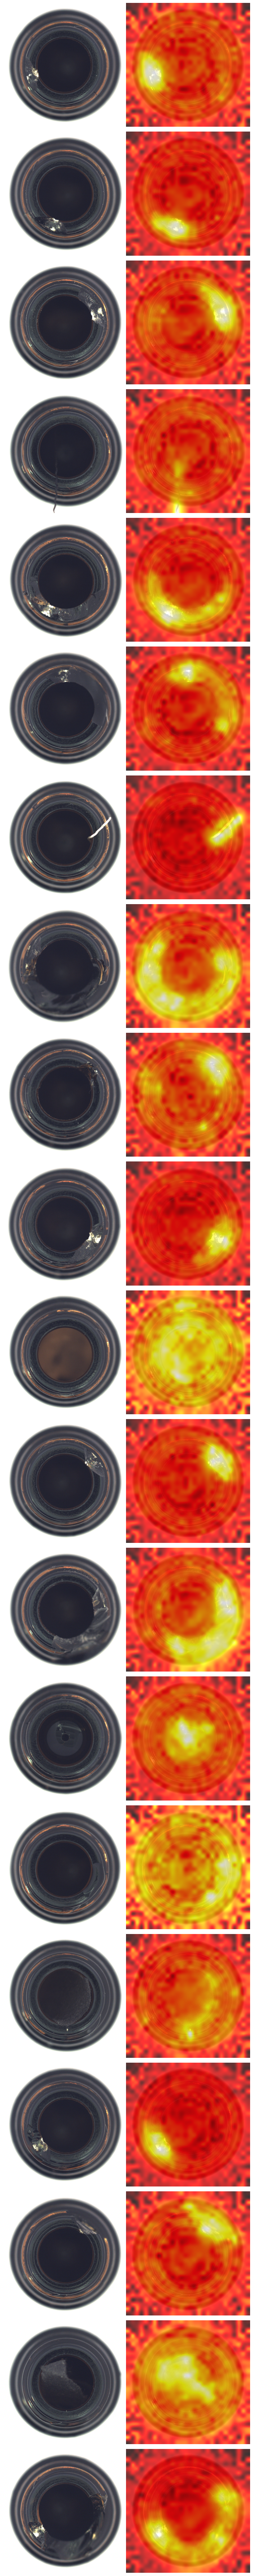

In [ ]:
N = 20
anomaly_idxs  = [i for i, label in enumerate(y_test) if label == 1]
sample_idxs   = random.sample(anomaly_idxs, k=min(N, len(anomaly_idxs)))

fig, axes = plt.subplots(N, 2, figsize=(8, N * 4))
fig.suptitle("Immagini anomale con heatmap PatchCore", fontsize=14, y=1.002)

for i, idx in enumerate(sample_idxs):
    img_raw         = testset_raw[idx][0]          # tensore [C, H, W] originale
    img_transformed = testset[idx][0]              # tensore [C, H, W] preprocessato

    anomaly_grid = get_anomaly_map(img_transformed.numpy())
    h, w = img_raw.shape[1], img_raw.shape[2]
    heatmap = get_heatmap(anomaly_grid, w, h)

    axes[i, 0].imshow(img_raw.permute(1, 2, 0))
    axes[i, 0].set_title("Originale", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_raw.permute(1, 2, 0))
    axes[i, 1].imshow(heatmap, cmap="hot", alpha=0.6)
    axes[i, 1].set_title("Heatmap anomalia", fontsize=9)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Calcolo anomaly score su tutto il test set...")
anomaly_scores = []

for i in tqdm(range(len(testset)), desc="Scoring"):
    img_transformed = testset[i][0]
    anomaly_grid    = get_anomaly_map(img_transformed.numpy())
    # Punteggio immagine = anomalia massima tra tutte le patch
    anomaly_scores.append(float(anomaly_grid.max()))

anomaly_scores = np.array(anomaly_scores)

auc = roc_auc_score(y_test, anomaly_scores)
print(f"\nAUC-ROC: {auc:.4f}")

# Distribuzione degli score per classe
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(anomaly_scores[y_test == 0], bins=30, alpha=0.6, label="Normali (y=0)", color="steelblue")
ax.hist(anomaly_scores[y_test == 1], bins=30, alpha=0.6, label="Anomalie (y=1)", color="tomato")
ax.set_xlabel("Anomaly score (max patch distance)")
ax.set_ylabel("Conteggio")
ax.set_title(f"Distribuzione degli anomaly score — AUC = {auc:.4f}")
ax.legend()
plt.tight_layout()
plt.show()